In [47]:
import pandas as pd

In [48]:
import matplotlib.pyplot as plt

In [49]:
import seaborn as sns

In [50]:
 df = pd.read_csv(r"C:\Users\lenovo\Downloads\airbnb (assignment).csv")

In [51]:
print(df.isnull().sum())

id                                  0
name                              271
host_id                             0
host_name                         127
neighbourhood_group                 0
neighbourhood                       5
latitude                            5
longitude                           0
room_type                           0
price                               0
minimum_nights                      0
number_of_reviews                   0
last_review                        13
reviews_per_month                  54
calculated_host_listings_count      1
availability_365                    0
dtype: int64


In [52]:
df['name']= df['name'].fillna('Unknown')

In [53]:
df['host_name']= df['host_name'].fillna('Unknown')

In [54]:
df['reviews_per_month']= df['reviews_per_month'].fillna(0)

In [55]:
df['neighbourhood_group'] = df['neighbourhood_group'].fillna('Unknown')

In [56]:
df['neighbourhood'] = df['neighbourhood'].fillna('Unknown')

In [57]:
df['last_review'] = df['last_review'].fillna('No Review')

In [58]:
df['latitude'] = df['latitude'].fillna(df['latitude'].median())

In [59]:
df['calculated_host_listings_count'] = df['calculated_host_listings_count'].fillna(1)

In [60]:
df.drop_duplicates(inplace=True)

In [61]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [62]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

In [63]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [64]:
df = df[(df['price'] >= lower_limit) & (df['price'] <= upper_limit)]

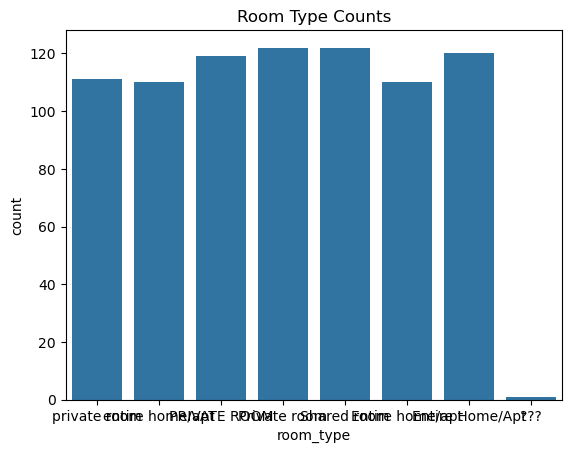

In [65]:
sns.countplot(data=df, x='room_type')
plt.title('Room Type Counts')
plt.show()

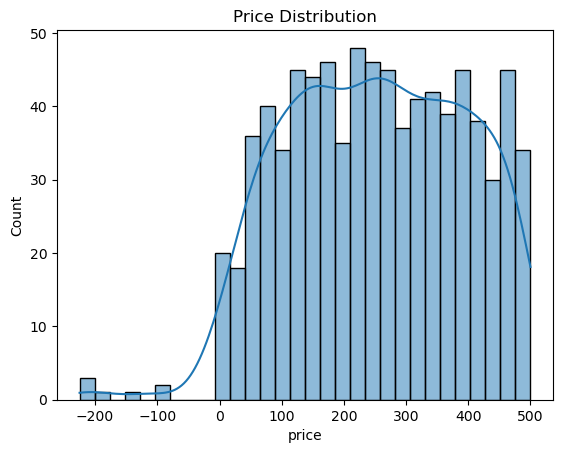

In [66]:
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Price Distribution')
plt.show()

In [68]:
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 815 entries, 1 to 1039
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              815 non-null    int64  
 1   name                            815 non-null    object 
 2   host_id                         815 non-null    object 
 3   host_name                       815 non-null    object 
 4   neighbourhood_group             815 non-null    object 
 5   neighbourhood                   815 non-null    object 
 6   latitude                        815 non-null    float64
 7   longitude                       815 non-null    object 
 8   room_type                       815 non-null    object 
 9   price                           815 non-null    float64
 10  minimum_nights                  815 non-null    object 
 11  number_of_reviews               815 non-null    object 
 12  last_review                     815 non-